# 3. Modeling 
### 3.1 Processed Data without thresholds for Air-Quality
### 3.2 Processed Data with thresholds for Air-Quality

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import sys
import os

# Add project root to path to use methods from src.utils
sys.path.append(os.path.abspath(".."))
from src.data_preprocessing import *

#### Heatmap of numeric data (same for 3.1 and 3.2)

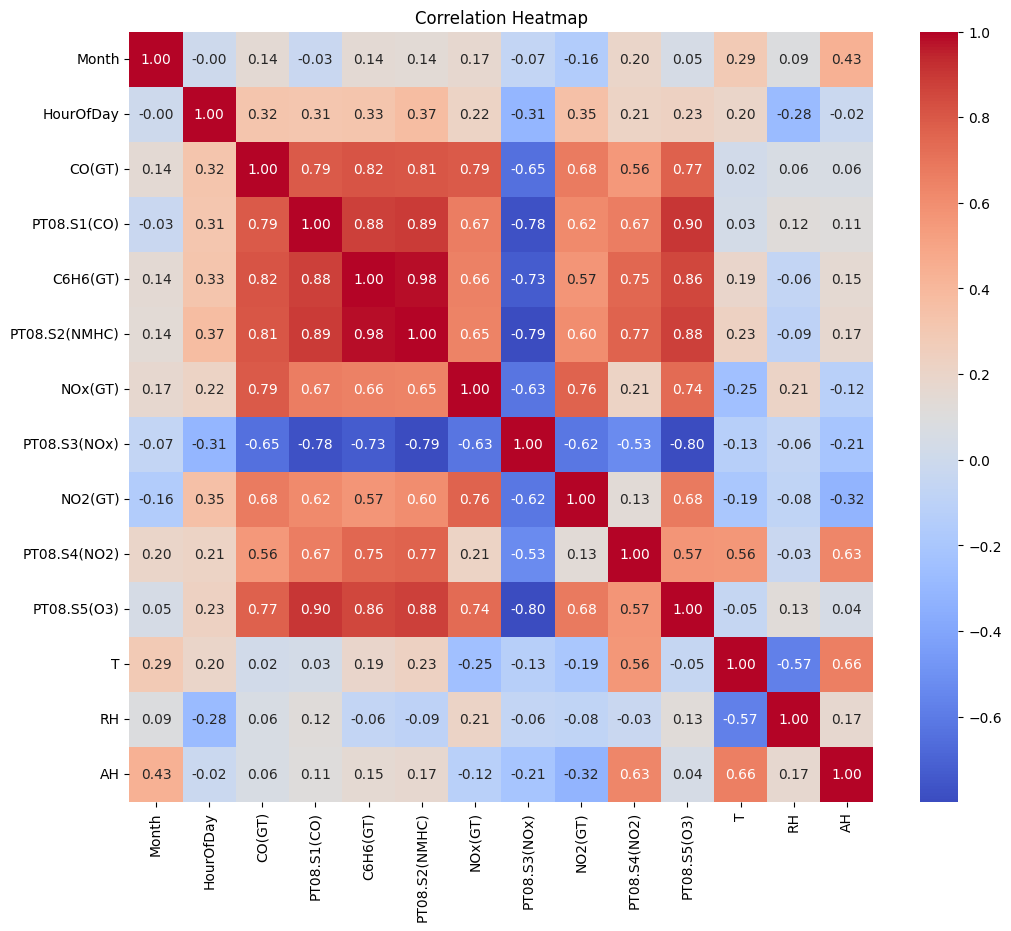

In [16]:
# Load your dataset(s)
df: pd.DataFrame = pd.read_csv('../data/AirQualityUCIProcessed.csv') # numeric data of both ...Processed... csv-files are the same!
df_thresholds: pd.DataFrame = pd.read_csv('../data/AirQualityUCIProcessedWithThresholds.csv')
df_numeric = df.select_dtypes(include='number') # numeric data of both ...Processed... csv-files are the same!

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### Heatmap interpretation
* Strong positive correlations (≥ 0.8) among key pollution sensors:
CO(GT), C6H6(GT), PT08.S1(CO), PT08.S2(NMHC), PT08.S5(O3) form a highly redundant cluster.
Indicates these sensors largely measure the same pollution sources.
* PT08.S3(NOx) sensor behaves differently:
Strongly negatively correlated (around -0.7 to -0.8) with other pollution sensors.
Reflects different chemical or atmospheric reactions, possibly ozone-NOx interaction.
* NOx(GT) and NO2(GT) show moderate positive correlation (~0.76):
Logical because NO2 is part of NOx compounds.
* Weather variables show expected physical patterns:
Temperature (T) positively correlated with absolute humidity (AH) (~0.66).
Temperature negatively correlated with relative humidity (RH) (~-0.57).
* Weather variables have weak correlations with pollution sensors:
Suggesting pollution levels are mainly driven by emissions rather than weather.
* Month shows weak correlations with pollutants and weather (~0.1–0.4):
Implies limited seasonality in pollution levels.
* Multicollinearity is present among pollution sensors:
Important for modeling—consider dimensionality reduction or feature selection.
* Sensor drift (not visible in heatmap) is a known challenge in this dataset:
Sensor responses change over time due to aging and environmental factors.
* Practical implications:
Reduce redundant features before modeling.
Consider the special role of PT08.S3(NOx) sensor.
Use weather variables carefully, as their impact is limited but physically consistent.

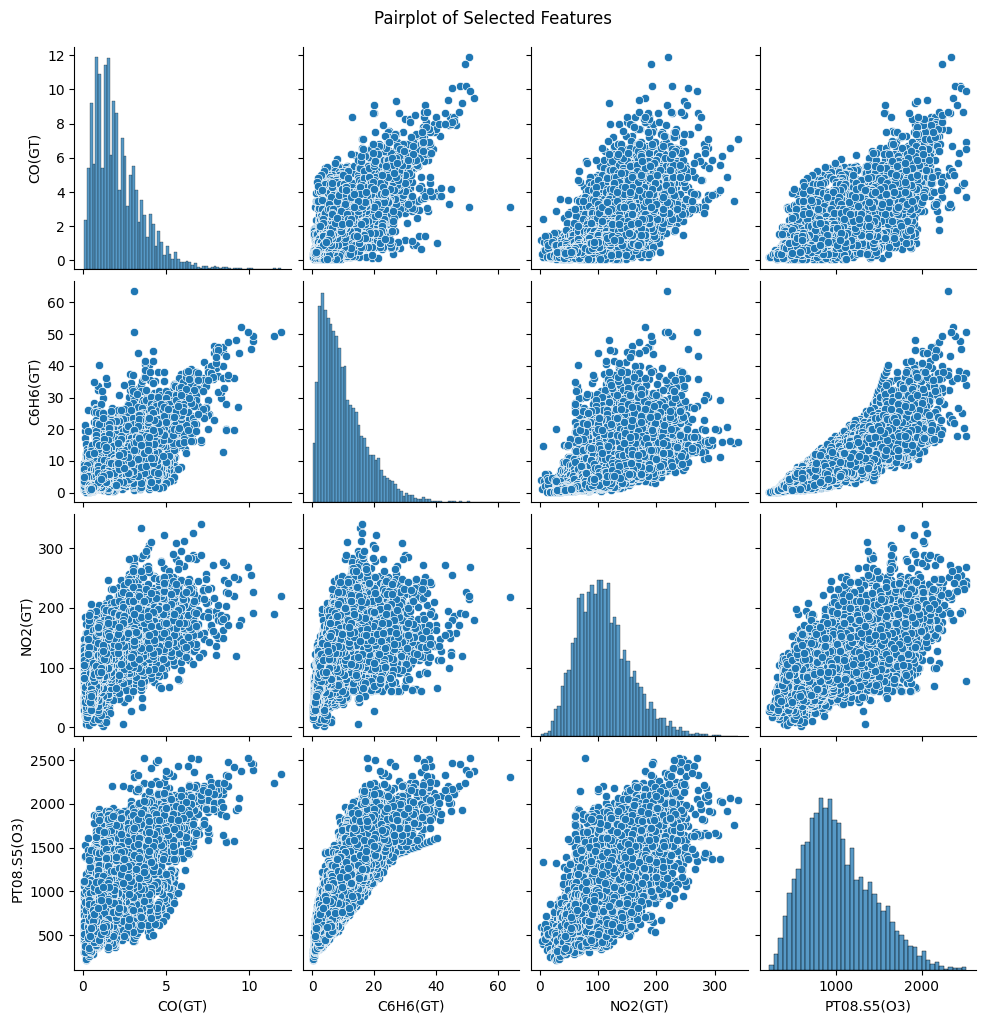

In [17]:
from sklearn.preprocessing import StandardScaler
import pickle

# 3.1 Select relevant features
features = ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S5(O3)', 'Month', 'HourOfDay', 'T', 'RH']
# Save variable 'features' for next notebook
with open('../data/features.pkl', 'wb') as file:
    pickle.dump(features, file)
X = df[features]

# 3.2 Select relevant features
features_with_thresholds = ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S5(O3)', 'Month', 'HourOfDay', 'T', 'RH', 'CO(GT)ToHigh', 'C6H6(GT)ToHigh', 'NO2(GT)ToHigh', 'PT08.S5(O3)ToHigh']
# Save variable 'features' for next notebook
with open('../data/features_with_thresholds.pkl', 'wb') as file:
    pickle.dump(features, file)
X_thresholds = df_thresholds[features_with_thresholds]

# Pairplot of selected features
features_to_plot = ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S5(O3)']
sns.pairplot(df[features_to_plot]) # takes 2 seconds
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

#### Interpretation:
* Strong positive correlations (scatterplots off diagonal)
* CO(GT) vs C6H6(GT): clear positive trend, moderately strong correlation (many points rising diagonally).
* CO(GT) vs PT08.S5(O3): strong positive trend with some spread.
* C6H6(GT) vs PT08.S5(O3): very clear, strong positive correlation, almost linear pattern.
* NO2(GT) positively correlates with all others but with more scatter, showing weaker but consistent relationships.
* These relationships confirm that these pollutants often increase and decrease together, likely due to common sources such as traffic emissions or industrial activity.

### 3.1 Processed Data without thresholds for Air-Quality

In [18]:
# Standardize the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X))

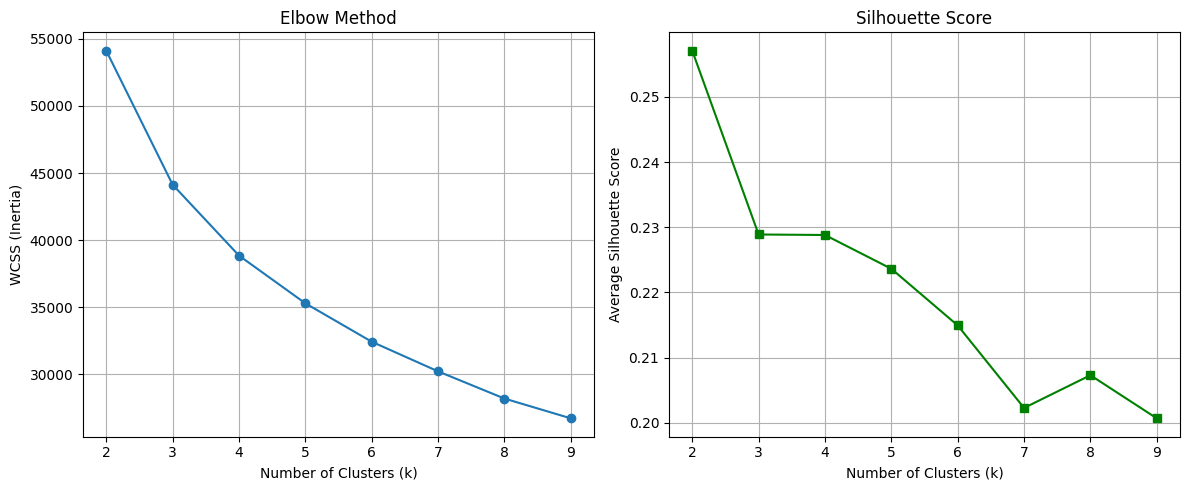

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# K-Means Clustering

# Evaluate range of K values
k_range = range(2, 10)  # NOTE: range from 2 to 10 normally a good starting point
wcss = []               # For Elbow Method
silhouette_scores = []  # For Silhouette Score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)          # NOTE: X or X_scaled depending on what you want to process
    wcss.append(kmeans.inertia_)  # Inertia = WCSS
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow Method (from prof. Carmen)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='green')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

#### Interpretation:
Both techniques suggest k = 3–4 as optimal. I will try '3' first, because I want to get three categories at the end:      
1) Green: low pollution
2) Yellow: moderate pollution
3) Red: high pollution conditions

Silhouette Score for k=3: 0.23


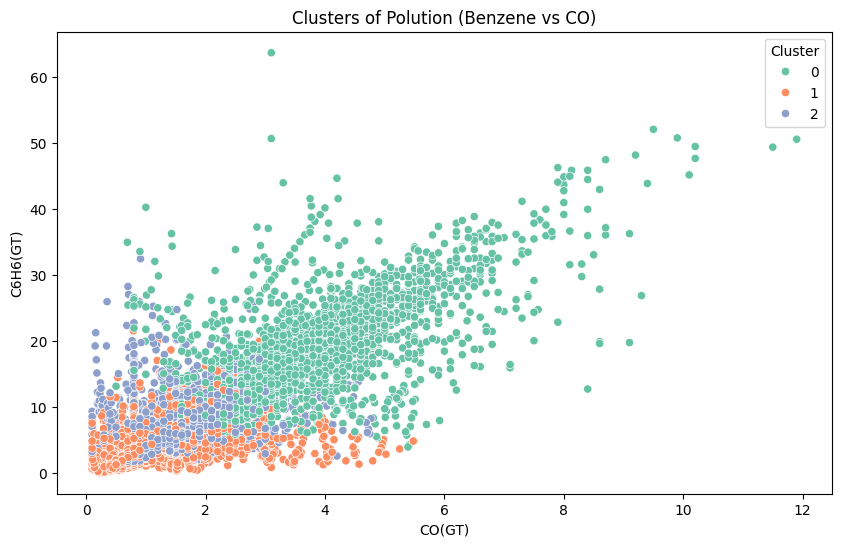

In [25]:
# Based on elbow plot, let's assume optimal k=3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = kmeans.labels_

# Silhouette Score
score = silhouette_score(X_scaled, kmeans.labels_)
print(f'Silhouette Score for k={k_optimal}: {score:.2f}')

# Visualize clusters
plt.figure(figsize=(10, 6))
col_x = 'CO(GT)'
col_y = 'C6H6(GT)'
sns.scatterplot(x=df[col_x], y=df[col_y], hue=df['Cluster'], palette='Set2')
plt.title(f'Clusters of Polution ({get_label_short(col_y)} vs {get_label_short(col_x)})')
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.legend(title='Cluster')
plt.show()

# Save datset with clusters
df.to_csv('../data/AirQualityUCIClustered.csv', index=False)

In [27]:
# Save kmeans-model
with open("../models/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# TODO: loading (check for model before running)
# with open("kmeans_model.pkl", "rb") as f:
#    model = pickle.load(f)

#### Try another technique for clustering: DBSCAN

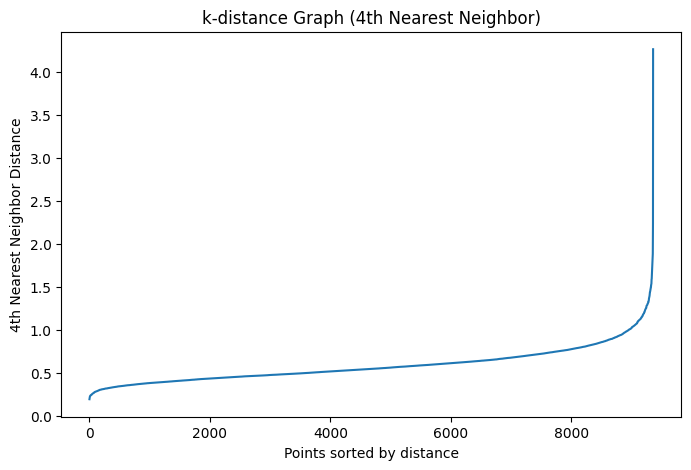


EPS: 1 - MIN_SAMPLES: 2
Clusters labels:
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]
Silhouette Score (excluding noise): -0.234

EPS: 1 - MIN_SAMPLES: 3
Clusters labels:
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
Silhouette Score (excluding noise): -0.111

EPS: 1 - MIN_SAMPLES: 4
Clusters labels:
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Silhouette Score (excluding noise): -0.119

EPS: 1 - MIN_SAMPLES: 5
Clusters labels:
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Silhouette Score (excluding noise): -0.113

EPS: 1.5 - MIN_SAMPLES: 2
Clusters labels:
[-1  0  1]
Silhouette Score (excluding noise): 0.508

EPS: 1.5 - MIN_SAMPLES: 3
Clusters labels:
[-1  0]

EPS: 1.5 - MIN_SAMPLES: 4
Clusters labels:
[-1  0  1]
Silhouette Score (excluding noise): 0.587

EPS: 1.5 - MIN_SAMPLES: 5
Clusters labels:
[-1  0  1]
Silhouette Score (excluding noise): 0.582

EPS: 2 

In [ ]:
# Try another model for clustering
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Use k-distance graph to choose eps
neighbors = NearestNeighbors(n_neighbors=4)  # 4th nearest neighbor
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title('k-distance Graph (4th Nearest Neighbor)')
plt.xlabel('Points sorted by distance')
plt.ylabel('4th Nearest Neighbor Distance')
plt.show()

# 2. Experiment with eps and min_samples (adjust eps based on graph)
eps_values = [1, 1.5, 2, 2.5, 3]
min_samples_values = [2, 3, 4, 5]

for eps_value in eps_values:
    for min_samples_value in min_samples_values:

        dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
        clusters = dbscan.fit_predict(X_scaled)

        print(f'\nEPS: {eps_value} - MIN_SAMPLES: {min_samples_value}')
        print(f'Clusters labels:\n{np.unique(clusters)}')

        # 3. Silhouette score excluding noise (-1 label)
        mask = clusters != -1
        if len(set(clusters[mask])) > 1:
            sil_score = silhouette_score(X_scaled[mask], clusters[mask])
            print(f'Silhouette Score (excluding noise): {sil_score:.3f}')
        else:
            continue
            # print("Silhouette Score cannot be computed with less than 2 clusters")

In [ ]:
# EPS: 1.5 - MIN_SAMPLES: 4
# Clusters labels:
# [-1  0  1]
# Silhouette Score (excluding noise): 0.587

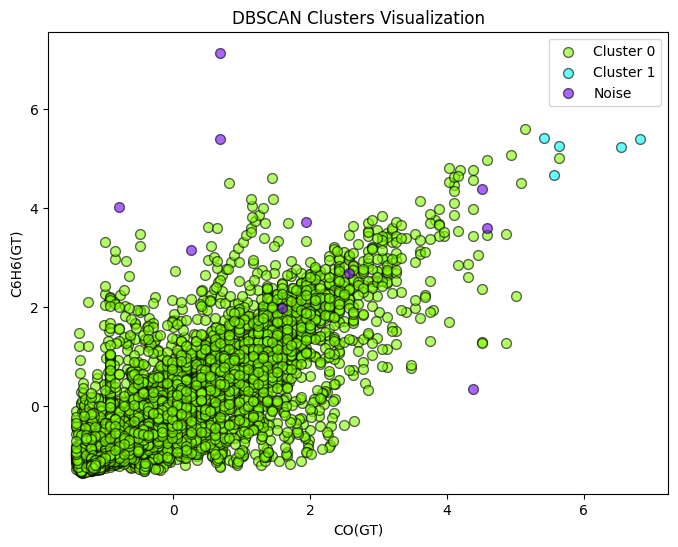

In [34]:
# USING BEST VALUES FROM ABOVE
eps_value = 1.5
min_samples_value = 4

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
clusters = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8,6))

unique_labels = set(clusters)
colors = sns.color_palette('hsv', len(unique_labels))

# Feature names from your features list
feature_x = features[0]
feature_y = features[1]

for k, col in zip(unique_labels, colors):

    class_member_mask = (clusters == k)
    xy = X_scaled[class_member_mask]

    label = 'Noise' if k == -1 else f'Cluster {k}'

    plt.scatter(
        xy.iloc[:,0],   # Feature 1
        xy.iloc[:,1],   # Feature 2
        c=[col],
        label=label,
        edgecolors='k',
        s=50,
        alpha=0.6
    )

plt.title('DBSCAN Clusters Visualization')
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.legend()
plt.show()


Explained Variance Ratio (2 components): [0.42024445 0.22081776]
Cumulative Variance: [0.42024445 0.64106221]


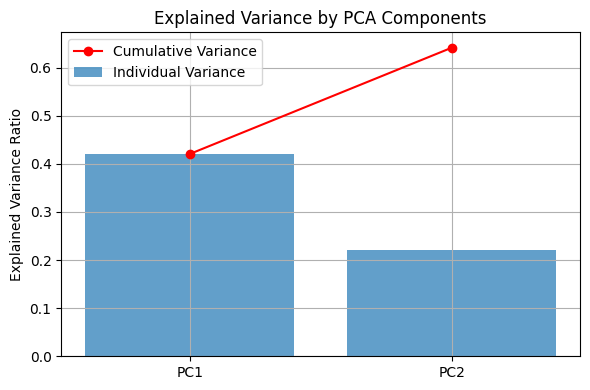

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Apply PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("\nExplained Variance Ratio (2 components):", explained_var)
'''
    This tells how much of the total variance (information) in your dataset is captured by each principal component:
	• Component 1 explains 42% of the variance.
	• Component 2 explains 22% of the variance.
'''
print("Cumulative Variance:", cumulative_var)
'''
    This is just the cumulative sum of the explained variance ratio:
	• After 1 component → 42% of total variance explained
	• After 2 components → 64% of total variance explained
'''

# Plot explained and cumulative variance
plt.figure(figsize=(6, 4))
plt.bar(['PC1', 'PC2'], explained_var, alpha=0.7, label='Individual Variance')
plt.plot(['PC1', 'PC2'], cumulative_var, marker='o', label='Cumulative Variance', color='red')
plt.title('Explained Variance by PCA Components')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# Feature importance for PC1
components_df = pd.Series(np.abs(pca.components_[0]), index=features)
components_df.sort_values(ascending=False).head(10)

C6H6(GT)       0.498242
CO(GT)         0.496742
PT08.S5(O3)    0.494216
NO2(GT)        0.437989
HourOfDay      0.255604
Month          0.044757
T              0.031114
RH             0.024765
dtype: float64

### 3.2 Processed Data with thresholds for Air-Quality

In [20]:
# Standardize the features
scaler_thresholds = StandardScaler()
X_scaled_thresholds = pd.DataFrame(scaler_thresholds.fit_transform(X_thresholds))

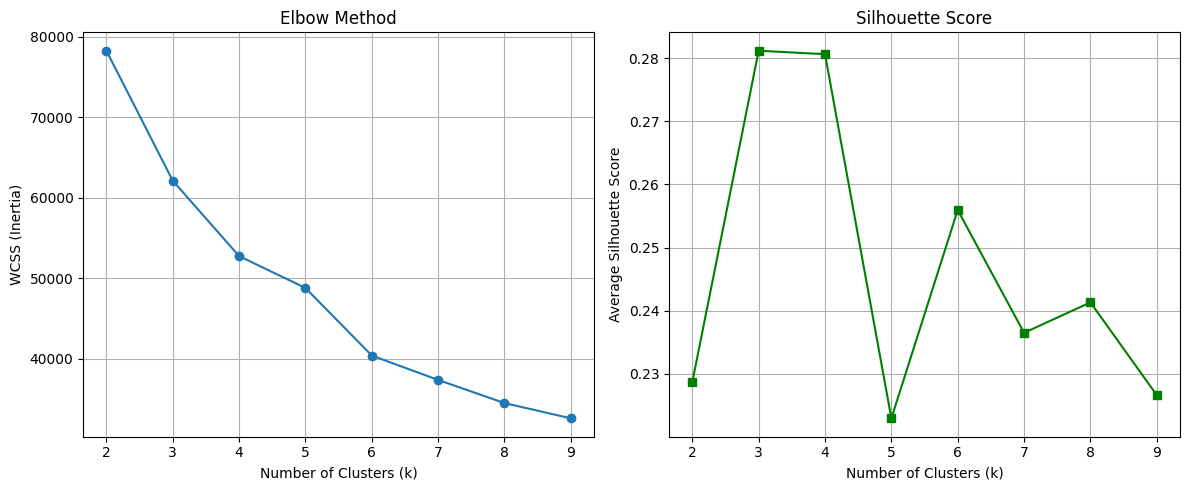

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# K-Means Clustering

# Evaluate range of K values
k_range_thresholds = range(2, 10)
wcss = []               # For Elbow Method
silhouette_scores = []  # For Silhouette Score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_thresholds)
    wcss.append(kmeans.inertia_)  # Inertia = WCSS
    silhouette_scores.append(silhouette_score(X_scaled_thresholds, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range_thresholds, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range_thresholds, silhouette_scores, marker='s', color='green')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

Silhouette Score for k=3: 0.28


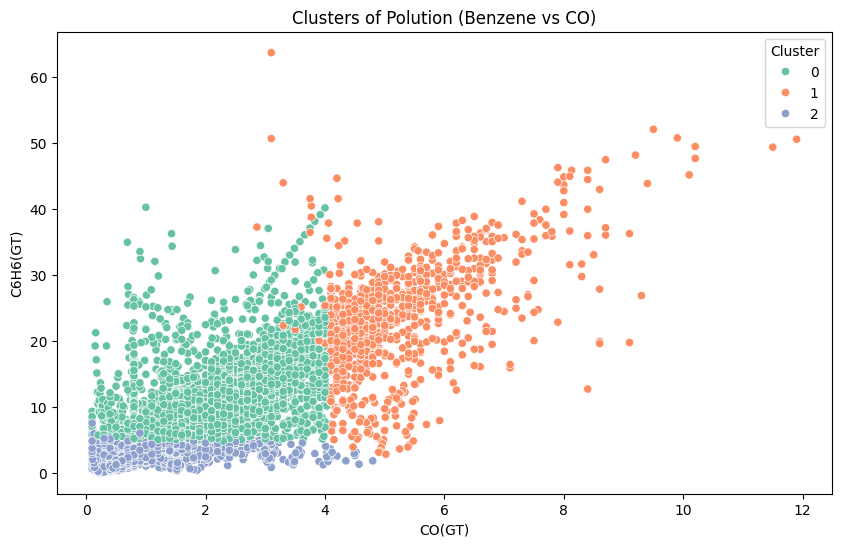

In [24]:
# Based on elbow plot, let's assume optimal k=3
k_optimal = 3
kmeans_thresholds = KMeans(n_clusters=k_optimal, random_state=42)
kmeans_thresholds.fit(X_scaled_thresholds)

# Add cluster labels to dataset
df_thresholds['Cluster'] = kmeans_thresholds.labels_

# Silhouette Score
score = silhouette_score(X_scaled_thresholds, kmeans_thresholds.labels_)
print(f'Silhouette Score for k={k_optimal}: {score:.2f}')

# Visualize clusters
plt.figure(figsize=(10, 6))
col_x = 'CO(GT)'
col_y = 'C6H6(GT)'
sns.scatterplot(x=df_thresholds[col_x], y=df_thresholds[col_y], hue=df_thresholds['Cluster'], palette='Set2')
plt.title(f'Clusters of Polution ({get_label_short(col_y)} vs {get_label_short(col_x)})')
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.legend(title='Cluster')
plt.show()

# Save datset with clusters
df.to_csv('../data/AirQualityUCIClusteredWithThresholds.csv', index=False)

In [28]:
# Save kmeans-model
with open("../models/kmeans_thresholds_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# TODO: loading (check for model before running)
# with open("kmeans_model.pkl", "rb") as f:
#    model = pickle.load(f)